<a href="https://colab.research.google.com/github/MZiaAfzal71/Melting-Point-Prediction-of-Boronic-Acids/blob/main/Data%20Files/Results/Statistical_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🧩 Colab Notebook: Statistical Significance Testing for XGBoost Results

## 🧠 Notebook Overview

This notebook evaluates the statistical significance of prediction differences between various molecular descriptors (e.g., MACCS, Morgan, Coulomb Matrix, Mordred, and the proposed Descriptor) using results from XGBoost models trained on Boronic Acid data.

It performs:

* Data collection from saved Excel files

* Error merging and visualization

* Normality testing (Shapiro–Wilk)

* Non-parametric Friedman Test for significance

* Post-hoc Nemenyi test for pairwise comparison

* Ranking plots and a final summary of findings

## 🧩 Cell 1: Install Required Statistical Packages

### Explanation:
Installs the scikit-posthocs library, which provides advanced non-parametric post-hoc tests (like the Nemenyi test).

This package complements SciPy’s friedmanchisquare test and helps identify which specific descriptor pairs differ significantly.

In [1]:
!pip install scikit_posthocs

## 🧱 Cell 2: Clone Repository and Navigate to Results Directory

### Explanation:
Clones the GitHub repository containing all Boronic Acid project data.
Then, moves into the Results directory, where all XGBoost outputs (for each descriptor) are stored.
These Excel files contain the columns: Name, Observed, Predicted, and Difference — which will be used in the statistical tests.

In [2]:
!git clone https://github.com/MZiaAfzal71/Melting-Point-Prediction-of-Boronic-Acids
%cd Melting-Point-Prediction-of-Boronic-Acids/Data\ Files/Results

Cloning into 'Melting-Point-Prediction-of-Boronic-Acids'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 354 (delta 47), reused 2 (delta 2), pack-reused 254 (from 2)
Receiving objects: 100% (354/354), 24.80 MiB | 20.39 MiB/s, done.
Resolving deltas: 100% (104/104), done.
/content/Melting-Point-Prediction-of-Boronic-Acids/Data Files/Results


## 🧠 Cell 3: Import Required Libraries

### Explanation:
* Imports essential libraries for:

* pandas/numpy: Data handling and manipulation

* scipy.stats: Normality (Shapiro–Wilk) and Friedman significance testing

* scikit_posthocs: Nemenyi post-hoc test for pairwise comparison

* seaborn/matplotlib: Data visualization (boxplots, barplots)

In [3]:
# 🧠 1. Import Required Libraries
import pandas as pd
import numpy as np
from scipy.stats import shapiro, friedmanchisquare
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

## 📂 Cell 4: Load XGBoost Results from All Descriptors

### Explanation:
* Reads each Excel file (for MACCS, Morgan, Coulomb Matrix, Mordred, and Descriptor) into separate DataFrames.
* Each contains four key columns: Name, Observed, Predicted, and Difference.
* Stores them in a dictionary called results for easy access and prints how many molecules were processed per descriptor.

In [4]:
# 📂 2. Load XGBoost Results from All Descriptors

# Define file paths (adjust paths if stored in subfolders)
files = {
    "MACCS": "MACCS_XGBoost_Results.xlsx",
    "Morgan": "Morgan_XGBoost_Results.xlsx",
    "CoulombMatrix": "CoulombMatrix_XGBoost_Results.xlsx",
    "Mordred": "Mordred_XGBoost_Results.xlsx",
    "Descriptor": "Descriptor_XGBoost_Results.xlsx"
}

# Load and store results in a dictionary
results = {}
for name, path in files.items():
    df = pd.read_excel(path)
    # Ensure consistent column names
    df.columns = df.columns.str.strip()
    results[name] = df[['Name', 'Observed', 'Predicted', 'Difference']]
    print(f"Loaded {name} ({len(df)} molecules).")


Loaded MACCS (605 molecules).
Loaded Morgan (605 molecules).
Loaded CoulombMatrix (605 molecules).
Loaded Mordred (605 molecules).
Loaded Descriptor (605 molecules).


## 🧹 Cell 5: Merge Results by Molecule Name

### Explanation:
* Aligns results across all descriptors by merging them using the Name column.
* This ensures that each molecule’s prediction errors from different descriptor-based models correspond to the same row.
* Rows with missing values are dropped to maintain fair comparison across models.

In [5]:
# 🧹 3. Merge Results Based on Molecule Names (Ensure Same Order)

# Merge on 'Name' column to align molecules across descriptor results
merged_df = results["MACCS"][["Name", "Observed"]].copy()

for desc, df in results.items():
    merged_df[f"{desc}_Error"] = df["Difference"]

# Drop any rows with missing errors
merged_df.dropna(inplace=True)
print(f"Merged dataset shape: {merged_df.shape}")
merged_df.head()


Merged dataset shape: (605, 7)


,Name,Observed,MACCS_Error,Morgan_Error,CoulombMatrix_Error,Mordred_Error,Descriptor_Error
0,Benzeneboronic acid,218.0,2.807709,10.108948,0.005234,0.003464,0.161591
1,4-methoxybenzeneboronic acid,204.0,28.094574,20.320343,0.024582,0.004395,12.856949
2,4-tolylboronic acid,259.0,79.542374,78.981964,99.879532,96.419540,19.330246
3,4-fluorophenylboronic acid,289.5,37.339706,1.971588,0.010406,0.003479,9.008118
4,4-chlorophenylboric acid,272.5,36.455917,12.512756,0.007904,0.006927,3.307220


## 📈 Cell 6: Visualize Error Distributions

### Explanation:
* Creates a boxplot comparing the distribution of absolute errors (Difference) for each descriptor.
* This visual overview helps detect outliers and gauge which descriptors produce tighter (more consistent) predictions.

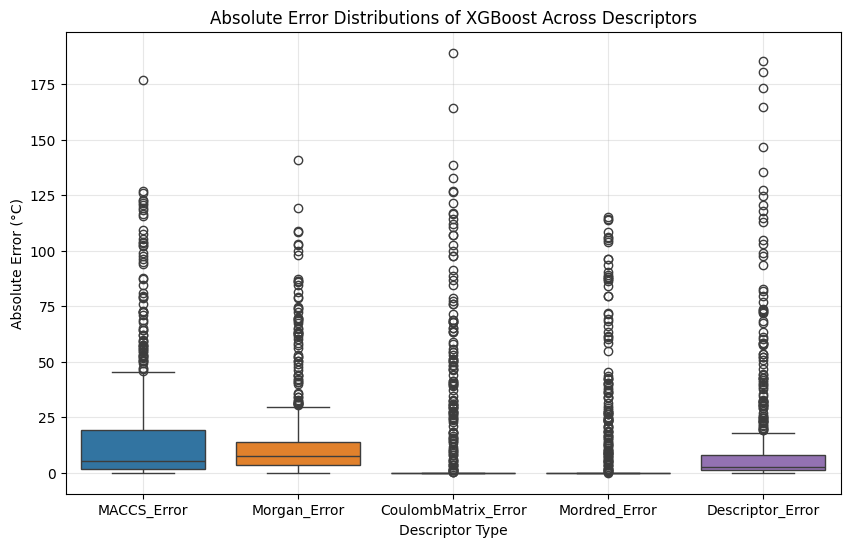

In [6]:
# 📈 4. Visualize Error Distributions for Quick Overview

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df[[f"{desc}_Error" for desc in results.keys()]])
plt.title("Absolute Error Distributions of XGBoost Across Descriptors")
plt.ylabel("Absolute Error (°C)")
plt.xlabel("Descriptor Type")
plt.grid(alpha=0.3)
plt.savefig("descriptors vs mae.pdf", dpi=500, bbox_inches ="tight")
plt.show()


## 🧮 Cell 7: Normality Check (Shapiro–Wilk Test)
### Explanation:
* Tests whether error values for each descriptor follow a normal distribution.
* If p < 0.05, the data is not normally distributed, meaning non-parametric tests (like Friedman) are more appropriate than ANOVA.

In [7]:
# 🧮 5. Check Normality of Error Differences (Shapiro-Wilk Test)
# Normality helps decide whether parametric or non-parametric tests are suitable.

print("Shapiro-Wilk normality test p-values:")
for desc in results.keys():
    stat, p = shapiro(merged_df[f"{desc}_Error"])
    print(f"{desc}: p = {p:.4f}")

print("\nIf p < 0.05 → not normal, use non-parametric tests (Friedman).")


Shapiro-Wilk normality test p-values:
MACCS: p = 0.0000
Morgan: p = 0.0000
CoulombMatrix: p = 0.0000
Mordred: p = 0.0000
Descriptor: p = 0.0000

If p < 0.05 → not normal, use non-parametric tests (Friedman).


## ⚖️ Cell 8: Friedman Test (Non-Parametric ANOVA Equivalent)

### Explanation:
Performs the Friedman test, which checks if there are statistically significant differences between multiple related groups (here, descriptors).

  * p < 0.05 → at least one descriptor’s performance differs significantly.

  * p ≥ 0.05 → no significant difference detected.

In [8]:
# ⚖️ 6. Friedman Test (Non-parametric ANOVA equivalent)

stat, p = friedmanchisquare(
    *[merged_df[f"{desc}_Error"] for desc in results.keys()]
)

print(f"Friedman Test Statistic: {stat:.4f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("✅ Significant difference detected among descriptor performances.")
else:
    print("❌ No statistically significant difference detected.")


Friedman Test Statistic: 1246.7412
p-value: 0.000000
✅ Significant difference detected among descriptor performances.


## 🔍 Cell 9: Post-hoc Nemenyi Test

### Explanation:
If the Friedman test detects significance, this post-hoc analysis identifies which specific pairs of descriptors differ.

The resulting table of p-values indicates pairwise differences — smaller values (< 0.05) mean statistically significant differences.

In [9]:
# 🔍 7. Post-hoc Analysis (Nemenyi Test) if Friedman is Significant

if p < 0.05:
    data = merged_df[[f"{desc}_Error" for desc in results.keys()]]
    nemenyi_results = sp.posthoc_nemenyi_friedman(data)
    print("\nPairwise Nemenyi Test p-values:")
    display(nemenyi_results)
else:
    print("Post-hoc test skipped (no significant differences detected).")



Pairwise Nemenyi Test p-values:


,MACCS_Error,Morgan_Error,CoulombMatrix_Error,Mordred_Error,Descriptor_Error
MACCS_Error,1.000000,1.253866e-01,0.000000e+00,0.000000e+00,3.196828e-05
Morgan_Error,0.125387,1.000000e+00,0.000000e+00,0.000000e+00,2.247480e-11
CoulombMatrix_Error,0.000000,0.000000e+00,1.000000e+00,3.315570e-11,0.000000e+00
Mordred_Error,0.000000,0.000000e+00,3.315570e-11,1.000000e+00,0.000000e+00
Descriptor_Error,0.000032,2.247480e-11,0.000000e+00,0.000000e+00,1.000000e+00


## 📊 Cell 10: Ranking Plot of Mean Errors

### Explanation:
Plots the average absolute error for each descriptor in ascending order.

This visual summary helps interpret performance ranking — descriptors with smaller mean errors perform better overall.

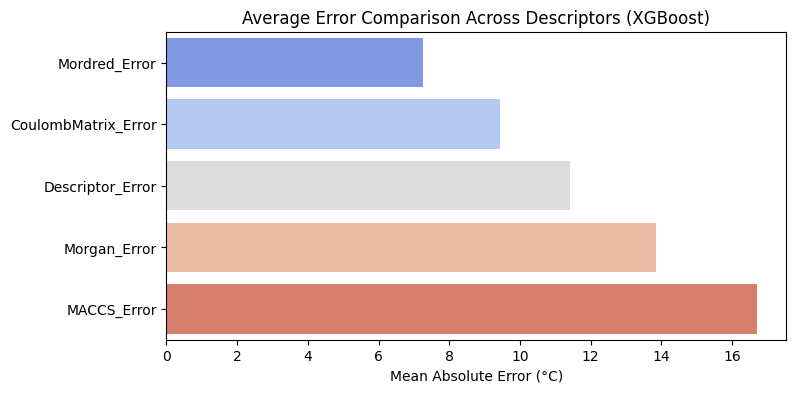

In [10]:
# 📊 8. Optional: Ranking Plot of Mean Errors

mean_errors = merged_df[[f"{desc}_Error" for desc in results.keys()]].mean().sort_values()
plt.figure(figsize=(8, 4))
sns.barplot(
    x=mean_errors.values,
    y=mean_errors.index,
    hue=mean_errors.index,     # assign y variable to hue
    palette="coolwarm",
    legend=False               # suppress legend
)

plt.xlabel("Mean Absolute Error (°C)")
plt.ylabel("")
plt.title("Average Error Comparison Across Descriptors (XGBoost)")
plt.savefig("average error comparisons.pdf", dpi=500, bbox_inches ="tight")
plt.show()


## 🧾 Cell 11: Summary Report

### Explanation:
Prints a concise numerical summary showing:

  * Mean and standard deviation of absolute errors per descriptor

  * Friedman test outcome interpretation
If significant differences were found, the earlier Nemenyi results identify the exact descriptor pairs that differ meaningfully.

In [11]:
# 🧾 9. Summary Report

print("===== Summary of Findings =====")
for desc in results.keys():
    mean_error = merged_df[f"{desc}_Error"].mean()
    std_error = merged_df[f"{desc}_Error"].std()
    print(f"{desc}: Mean Error = {mean_error:.3f}, Std = {std_error:.3f}")

print("\nFriedman p-value interpretation:")
print("- p < 0.05 → significant differences in performance across descriptors.")
print("- Use Nemenyi test table above to identify which pairs differ.")


===== Summary of Findings =====
MACCS: Mean Error = 16.705, Std = 26.191
Morgan: Mean Error = 13.838, Std = 19.820
CoulombMatrix: Mean Error = 9.434, Std = 25.840
Mordred: Mean Error = 7.258, Std = 20.599
Descriptor: Mean Error = 11.417, Std = 25.134

Friedman p-value interpretation:
- p < 0.05 → significant differences in performance across descriptors.
- Use Nemenyi test table above to identify which pairs differ.
